In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras import layers, models

# ==========================================
# 1. AUTO-DETECT DATASET PATH
# ==========================================
print("Mencari lokasi dataset...")
found_train = None
found_test = None

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if 'train.csv' in filename:
            found_train = os.path.join(dirname, filename)
        if 'test.csv' in filename:
            found_test = os.path.join(dirname, filename)

if found_train and found_test:
    print(f"Dataset ditemukan!\nTrain: {found_train}\nTest: {found_test}")
    train_data = pd.read_csv(found_train)
    test_data = pd.read_csv(found_test)
else:
    raise FileNotFoundError("Dataset train.csv atau test.csv tidak ditemukan. Pastikan sudah klik '+ Add Input'.")

# ==========================================
# 2. PREPROCESSING
# ==========================================
print("Melakukan Preprocessing...")
# Menghapus kolom 'Activity' (target) dan 'subject'
X_train = train_data.drop(['Activity', 'subject'], axis=1).values
y_train = train_data['Activity'].values
X_test = test_data.drop(['Activity', 'subject'], axis=1).values
y_test = test_data['Activity'].values

# Encode label aktivitas menjadi angka
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Reshape untuk input CNN-Transformer: (sampel, sequence_length, features)
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

# ==========================================
# 3. BUILD MODEL HYBRID CNN-TRANSFORMER
# ==========================================
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
    res = x + inputs
    
    x = layers.LayerNormalization(epsilon=1e-6)(res)
    x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation="relu")(x)
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    return x + res

# Input sesuai dengan fitur UCI HAR (561)
inputs = layers.Input(shape=(1, 561))

# Bagian CNN
x = layers.Conv1D(64, 1, activation="relu", padding="same")(inputs)
x = layers.Dropout(0.2)(x)

# Bagian Transformer
x = transformer_encoder(x, head_size=128, num_heads=4, ff_dim=128, dropout=0.1)

# Output Layer
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(len(le.classes_), activation="softmax")(x)

model = models.Model(inputs, outputs)
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

model.summary()

# ==========================================
# 4. TRAINING
# ==========================================
print("\nMemulai Training... Screenshot hasil ini untuk BAB IV!")
history = model.fit(
    X_train, y_train_encoded, 
    epochs=15, 
    batch_size=32,
    validation_data=(X_test, y_test_encoded)
)

# ==========================================
# 5. SIMPAN MODEL
# ==========================================
if not os.path.exists('models'):
    os.makedirs('models')

model_path = 'models/model_final.h5'
model.save(model_path)

print(f"\nSelesai! Model disimpan di: {model_path}")
print("Silakan ambil grafik akurasi/loss terakhir untuk laporan tesis Anda.")

2026-05-06 00:26:25.454016: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778027185.654158      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778027185.714685      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778027186.178934      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778027186.178977      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778027186.178980      57 computation_placer.cc:177] computation placer alr

Mencari lokasi dataset...
Dataset ditemukan!
Train: /kaggle/input/datasets/organizations/uciml/human-activity-recognition-with-smartphones/train.csv
Test: /kaggle/input/datasets/organizations/uciml/human-activity-recognition-with-smartphones/test.csv
Melakukan Preprocessing...


I0000 00:00:1778027210.007496      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1, 561)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 1, 64)     │     35,968 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1, 64)     │          0 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 1, 64)     │        128 │ dropout[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1, 64)     │    132,672 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 64)     │          0 │ multi_head_atten… │
│                     │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1, 64)     │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 1, 128)    │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 1, 64)     │      8,256 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1, 64)     │          0 │ conv1d_2[0][0],   │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ add_1[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 6)         │        390 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

...

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 4, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
I0000 00:00:1778027214.249893     129 service.cc:152] XLA service 0x7fefb4012880 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778027214.249929     129 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778027214.813107     129 cuda_dnn.cc:529] Loaded cuDNN version 91002


 56/230 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4678 - loss: 1.3751

I0000 00:00:1778027217.914623     129 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


230/230 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.6658 - loss: 0.8267 - val_accuracy: 0.8894 - val_loss: 0.2788
Epoch 2/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8889 - loss: 0.2756 - val_accuracy: 0.8646 - val_loss: 0.3163
Epoch 3/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9165 - loss: 0.2035 - val_accuracy: 0.8795 - val_loss: 0.3503
Epoch 4/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9255 - loss: 0.1836 - val_accuracy: 0.9169 - val_loss: 0.2151
Epoch 5/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9461 - loss: 0.1460 - val_accuracy: 0.9267 - val_loss: 0.2385
Epoch 6/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9453 - loss: 0.1470 - val_accuracy: 0.9467 - val_loss: 0.1420
Epoch 7/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9404 - loss: 0.1482 - val_accuracy: 0.9552 - val_loss: 0.1194
Epoch 8/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9525 - loss: 0.1286 - val_accuracy: 0.9287 - va


Selesai! Model disimpan di: models/model_final.h5
Silakan ambil grafik akurasi/loss terakhir untuk laporan tesis Anda.


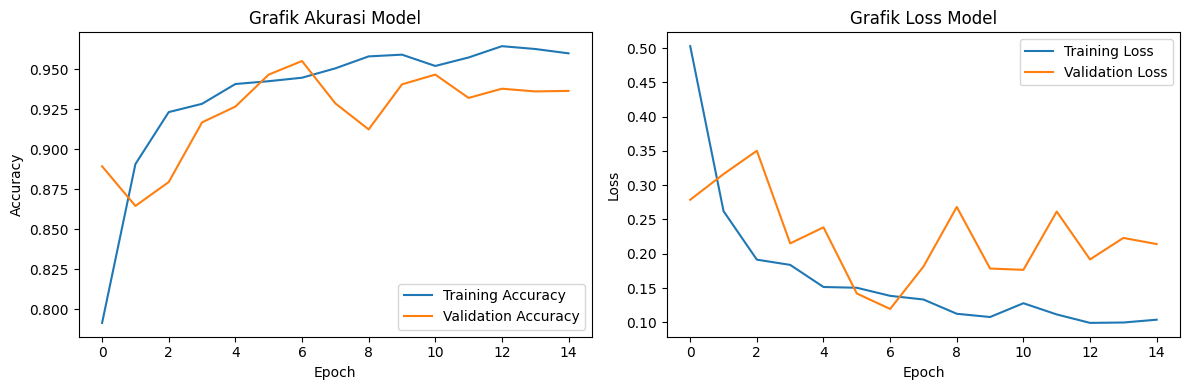

In [2]:
import matplotlib.pyplot as plt

# Grafik Akurasi
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Grafik Akurasi Model')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Grafik Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Grafik Loss Model')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis 3 of a tensor of shape (32, 4, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


70/93 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 4, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


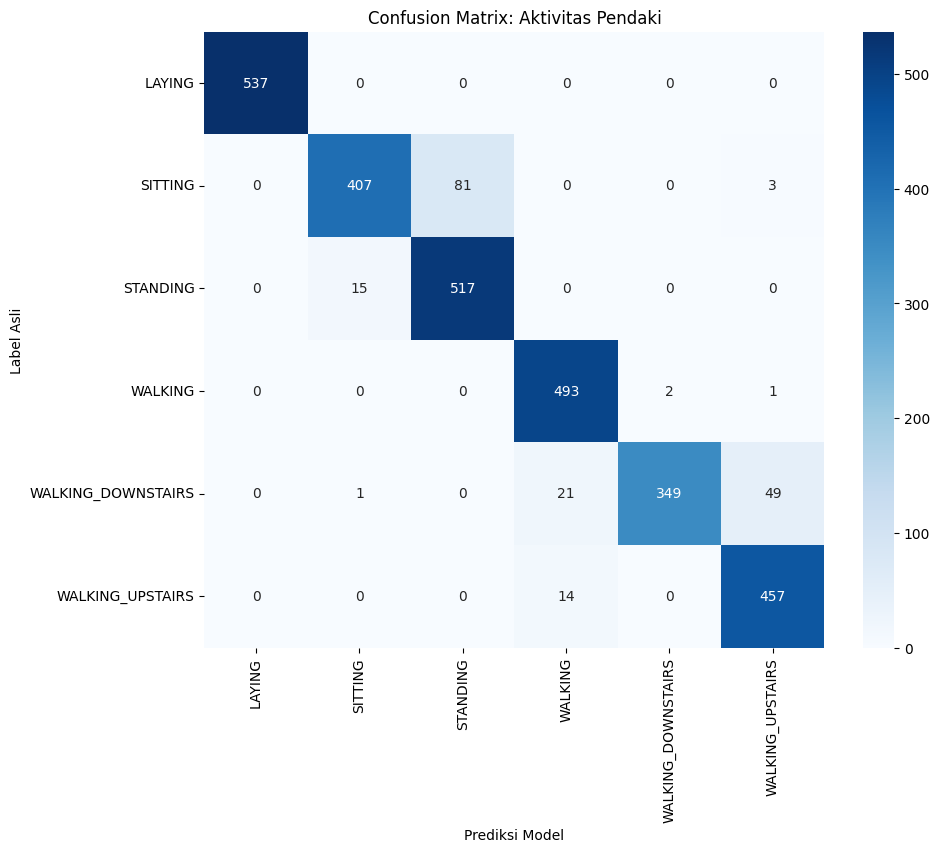


Laporan Klasifikasi Lengkap:

                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.96      0.83      0.89       491
          STANDING       0.86      0.97      0.92       532
           WALKING       0.93      0.99      0.96       496
WALKING_DOWNSTAIRS       0.99      0.83      0.91       420
  WALKING_UPSTAIRS       0.90      0.97      0.93       471

          accuracy                           0.94      2947
         macro avg       0.94      0.93      0.93      2947
      weighted avg       0.94      0.94      0.94      2947



In [3]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Prediksi data test
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# 2. Buat Confusion Matrix
cm = confusion_matrix(y_test_encoded, y_pred_classes)

# 3. Visualisasi dengan Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, 
            yticklabels=le.classes_)
plt.title('Confusion Matrix: Aktivitas Pendaki')
plt.ylabel('Label Asli')
plt.xlabel('Prediksi Model')
plt.show()

# 4. Tampilkan Classification Report (Precision, Recall, F1-Score)
print("\nLaporan Klasifikasi Lengkap:\n")
print(classification_report(y_test_encoded, y_pred_classes, target_names=le.classes_))